### Laplacian Edge Detection

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


In [2]:
pathImg = r"C:\Users\COMPUTER WORLD\Desktop/DIPproject/Images/zebra.png"
img = cv.imread(pathImg, cv.IMREAD_GRAYSCALE)
type(img), img.shape

(numpy.ndarray, (181, 200))

In [3]:
def edgeMask_laplacian(img: np.ndarray, sensitivity: float = 40, strictness: int = 2) -> np.ndarray:
    r, c = img.shape
    
    mask = np.zeros((r, c), dtype='uint8')
    img1 = cv.copyMakeBorder(img, 1, 1, 1, 1, borderType=cv.BORDER_REPLICATE)

    del2 = np.array([
        [1, 4, 1],
        [4, -20, 4],
        [1, 4, 1]
    ])
    for i in range(1, r+1):
        curr:float = 0.0
        for j in range(1, c+1):
            window = img1[i-1 : i+2, j-1 : j+2]
            curr = (np.sum(del2*window)/(sensitivity))
            if(curr<=127 and curr>= -128): mask[i-1][j-1] = int(curr) + 128
            elif(curr<=128): mask[i-1][j-1] = 0
            else: mask[i][j] = 255 
                
    a = np.where((mask >= 128 - strictness) & (mask <= 128 + strictness), 0, 255)
    return a
   

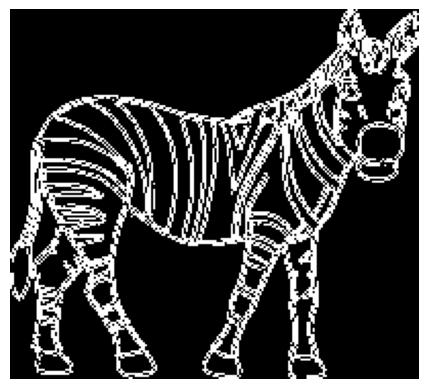

True

In [4]:
edge = edgeMask_laplacian(img, sensitivity=250, strictness=1)

plt.imshow(edge, cmap='gray')   # use cmap='gray' for grayscale
plt.axis('off')
plt.show()

cv.imwrite("OutputLaplacian.jpg", edge)